In [1]:
import os, datetime, sys, time, traceback

import pandas as pd
import numpy as np
import pickle as pkl
import multiprocessing as mp
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from statsmodels.distributions.empirical_distribution import ECDF
from skfda.exploratory.depth import ModifiedBandDepth
from functional_utils import _confidence_bands_from_eCDF
from scipy import stats
from functools import partial

from sklearn.neighbors import KernelDensity

from ffc_utils import (_fknn_forecast_dynamic_update,
                       _functional_downsampling, 
                       _focal_curve_envelope, 
                       _functional_confidence_band,
                       _silverman_rule)

from scores_utils import _empirical_PIT, _KS

path_to_data = '/home/gterren/dynamic_update/data'
path_to_validation = '/home/gterren/dynamic_update/validation'
path_to_param = '/home/gterren/dynamic_update/params'
path_to_test = '/home/gterren/dynamic_update/test'
path_to_images = '/home/gterren/dynamic_update/images'

# Calibration experiments setup
T = 288
resource = 'wind'
method   = 'fusion'

In [2]:
# Load 2017 data as training set
with open(path_to_data + f"/preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
#print(assets_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
print(F_tr_.shape, E_tr_.shape)
    
# Load 2018 data as testing set
with open(path_to_data + f"/preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
F_ts_      = _data["observations"]
E_ts_      = _data["forecasts"]
#print(assets_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
#print(F_ts_.shape, E_ts_.shape)

# Short testing set with training set order
order  = {v: i for i, v in enumerate(assets_tr_)}
idx_   = np.argsort([order[x] for x in assets_ts_])
F_ts_  = F_ts_[:, :, idx_]
E_ts_  = E_ts_[:, :, idx_]
print(F_ts_.shape, E_ts_.shape)

# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
#print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))

# No possble a capacity factor is larger than 1 or smaller than 0
F_tr_[F_tr_ > 1.] = 1.
F_ts_[F_ts_ > 1.] = 1.
E_tr_[E_tr_ > 1.] = 1.
E_ts_[E_ts_ > 1.] = 1.
print(F_tr_.max(), E_tr_.max())
print(F_tr_.max(), E_tr_.min())

F_tr_[F_tr_ < 0.] = 0.
F_ts_[F_ts_ < 0.] = 0.
E_tr_[E_tr_ < 0.] = 0.
E_ts_[E_ts_ < 0.] = 0.
print(F_ts_.max(), F_ts_.max())
print(F_ts_.min(), E_ts_.min())

F_tr_ /= F_tr_.max()
F_ts_ /= F_ts_.max()
E_tr_ /= E_tr_.max()
E_ts_ /= E_ts_.max()

# Format training set from day x interval x asset to [day * asset] x interval
E_ts_bias_ = E_ts_.copy()
E_tr_bias_ = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
print(E_tr_bias_.shape, E_ts_bias_.shape)

(363, 288, 187) (363, 288, 187)
(364, 288, 187) (364, 288, 187)
1.0 0.9999999888984703
1.0 0.0
1.0 1.0
0.0 0.0
(67881, 288) (364, 288, 187)


(363, 288, 187) (363, 288, 187)


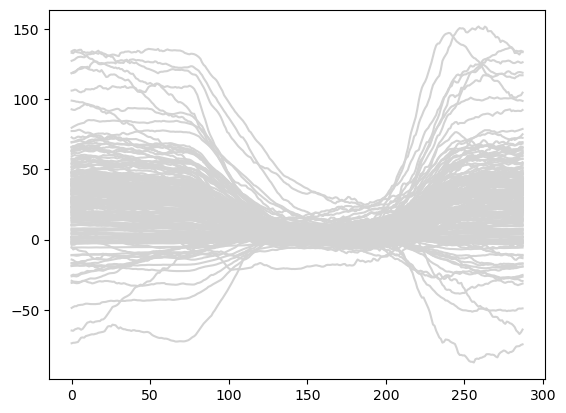

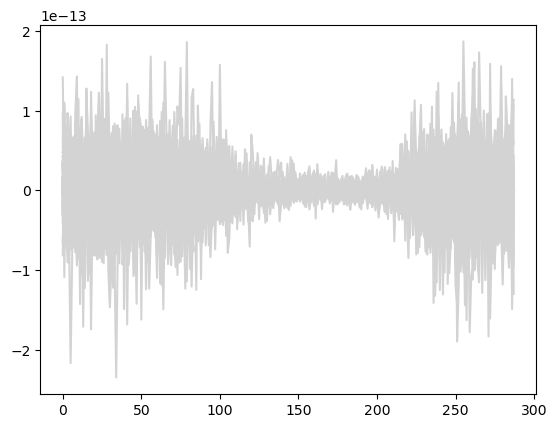

(364, 288, 187) (364, 288, 187)


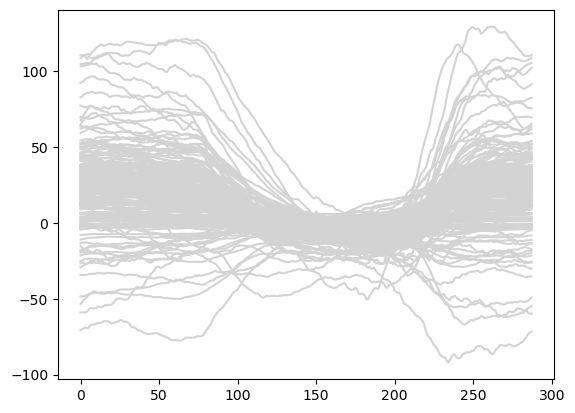

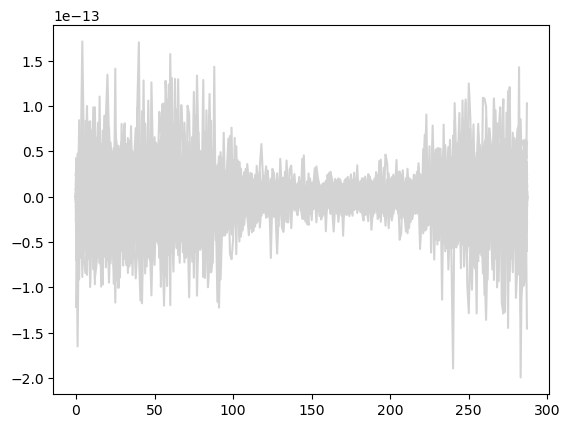

In [3]:
# Load 2017 data as training set
with open(path_to_data + f"/linear_preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
#print(assets_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
print(F_tr_.shape, E_tr_.shape)

plt.figure()
plt.plot(np.mean(F_tr_ - E_tr_, axis = 0), c = 'lightgray')
plt.show()

# Unbias training set
B_tr_ = np.mean(F_tr_ - E_tr_, axis = 0)
for i in range(E_tr_.shape[-1]):
    E_tr_[:, :, i] += B_tr_[:, i]

plt.figure()
plt.plot(np.mean(F_tr_ - E_tr_, axis = 0), c = 'lightgray')
plt.show()

# Load 2018 data as testing set
with open(path_to_data + f"/linear_preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
F_ts_      = _data["observations"]
E_ts_      = _data["forecasts"]
#print(assets_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
#print(F_ts_.shape, E_ts_.shape)

# Short testing set with training set order
order  = {v: i for i, v in enumerate(assets_tr_)}
idx_   = np.argsort([order[x] for x in assets_ts_])
F_ts_  = F_ts_[:, :, idx_]
E_ts_  = E_ts_[:, :, idx_]
print(F_ts_.shape, E_ts_.shape)

plt.figure()
plt.plot(np.mean(F_ts_ - E_ts_, axis = 0), c = 'lightgray')
plt.show()

# Unbias testing set
B_ts_ = np.mean(F_ts_ - E_ts_, axis = 0)
for i in range(E_ts_.shape[-1]):
    E_ts_[:, :, i] += B_ts_[:, i]

plt.figure()
plt.plot(np.mean(F_ts_ - E_ts_, axis = 0), c = 'lightgray')
plt.show()

# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
# print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))

# No possble a capacity factor is larger than 1 or smaller than 0
F_tr_[F_tr_ > 1.] = 1.
F_ts_[F_ts_ > 1.] = 1.
E_tr_[E_tr_ > 1.] = 1.
E_ts_[E_ts_ > 1.] = 1.

F_tr_[F_tr_ < 0.] = 0.
F_ts_[F_ts_ < 0.] = 0.
E_tr_[E_tr_ < 0.] = 0.
E_ts_[E_ts_ < 0.] = 0.

F_tr_ /= F_tr_.max()
F_ts_ /= F_ts_.max()
E_tr_ /= E_tr_.max()
E_ts_ /= E_ts_.max()

# Format training set from day x interval x asset to [day * asset] x interval
E_ts_lin_ = E_ts_.copy()
E_tr_lin_ = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
#print(E_tr_lin_.shape, E_ts_lin_.shape)

(363, 288, 187) (363, 288, 187) (363, 288)


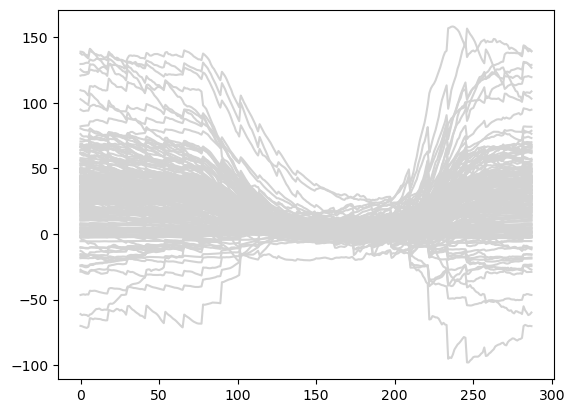

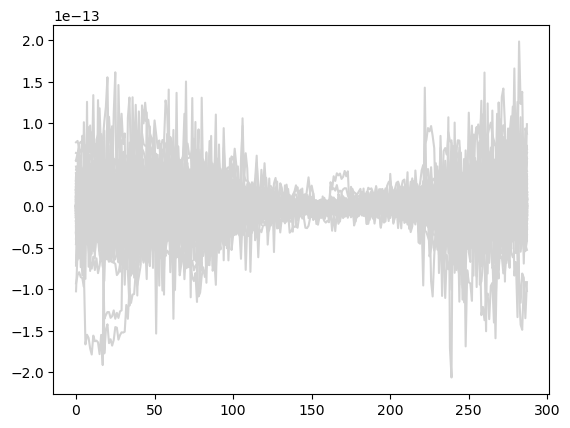

(364, 288, 187) (364, 288, 187) (364, 288)


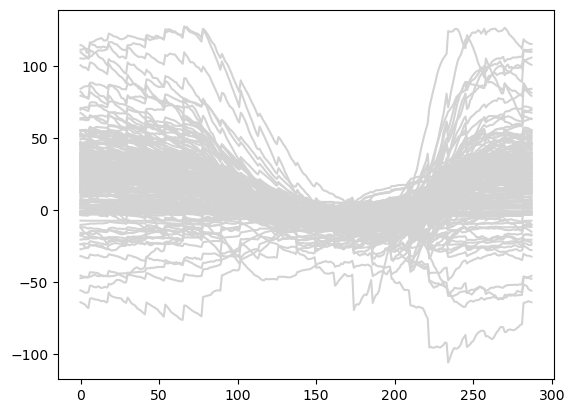

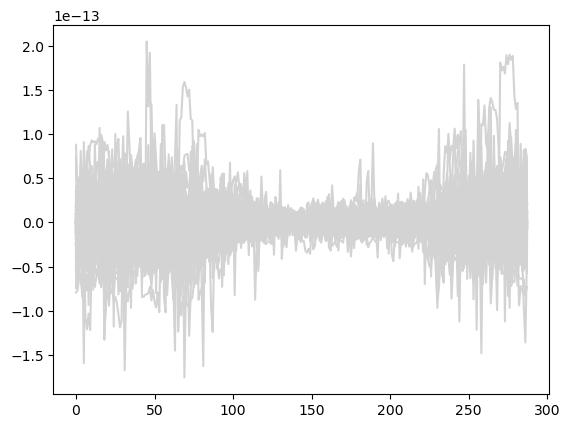

In [4]:
# Load 2017 data as training set
with open(path_to_data + f"/preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
x_tr_      = _data["locations"]
dates_tr_  = _data["dates"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
#print(assets_tr_.shape, x_tr_.shape, dates_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
T_tr_ = dates_tr_.reshape(int(dates_tr_.shape[0]/T), T)
print(F_tr_.shape, E_tr_.shape, T_tr_.shape)

plt.figure()
plt.plot(np.mean(F_tr_ - E_tr_, axis = 0), c = 'lightgray')
plt.show()

# Unbias training set
B_tr_ = np.mean(F_tr_ - E_tr_, axis = 0)
for i in range(E_tr_.shape[-1]):
    E_tr_[:, :, i] += B_tr_[:, i]

plt.figure()
plt.plot(np.mean(F_tr_ - E_tr_, axis = 0), c = 'lightgray')
plt.show()

# Load 2018 data as testing set
with open(path_to_data + f"/preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
x_ts_      = _data["locations"]
dates_ts_  = _data["dates"]
F_ts_      = _data["observations"]
E_ts_      = _data["forecasts"]
#print(assets_ts_.shape, x_ts_.shape, dates_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
T_ts_ = dates_ts_.reshape(int(dates_ts_.shape[0]/T), T)
print(F_ts_.shape, E_ts_.shape, T_ts_.shape)

dt_ = np.array([t * 5 for t in range(T)])
dx_ = pd.to_datetime(pd.DataFrame({"time": dt_}).time, unit = "m").dt.strftime("%H:%M").to_numpy()
#print(dt_.shape, dx_.shape)

# Short testing set with training set order
order      = {v: i for i, v in enumerate(assets_tr_)}
idx_       = np.argsort([order[x] for x in assets_ts_])
assets_ts_ = assets_ts_[idx_]
x_ts_      = x_ts_[idx_]
F_ts_      = F_ts_[:, :, idx_]
E_ts_      = E_ts_[:, :, idx_]
#print(F_ts_.shape, E_ts_.shape, T_ts_.shape)

plt.figure()
plt.plot(np.mean(F_ts_ - E_ts_, axis = 0), c = 'lightgray')
plt.show()

# Unbias testing set
B_ts_ = np.mean(F_ts_ - E_ts_, axis = 0)
for i in range(E_ts_.shape[-1]):
    E_ts_[:, :, i] += B_ts_[:, i]
    
plt.figure()
plt.plot(np.mean(F_ts_ - E_ts_, axis = 0), c = 'lightgray')
plt.show()


# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
#print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))

# No possble a capacity factor is larger than 1 or smaller than 0
F_tr_[F_tr_ > 1.] = 1.
F_ts_[F_ts_ > 1.] = 1.
E_tr_[E_tr_ > 1.] = 1.
E_ts_[E_ts_ > 1.] = 1.

F_tr_[F_tr_ < 0.] = 0.
F_ts_[F_ts_ < 0.] = 0.
E_tr_[E_tr_ < 0.] = 0.
E_ts_[E_ts_ < 0.] = 0.

F_tr_ /= F_tr_.max()
F_ts_ /= F_ts_.max()
E_tr_ /= E_tr_.max()
E_ts_ /= E_ts_.max()

# Format training set from day x interval x asset to [day * asset] x interval
T_tr_ = np.concatenate([T_tr_ for k in range(assets_tr_.shape[0])], axis = 0)
assets_tr_ = np.concatenate([np.tile(assets_tr_[k], (F_tr_.shape[0], 1)) for k in range(assets_tr_.shape[0])], axis = 0)
x_tr_ = np.concatenate([np.tile(x_tr_[k, :], (F_tr_.shape[0], 1)) for k in range(x_tr_.shape[0])], axis = 0)
F_tr_ = np.concatenate([F_tr_[..., k] for k in range(F_tr_.shape[2])], axis = 0)
E_tr_ = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
#print(x_tr_.shape, assets_tr_.shape, F_tr_.shape, E_tr_.shape, T_tr_.shape)
#print(x_ts_.shape, assets_ts_.shape, F_ts_.shape, E_ts_.shape, T_ts_.shape)

t_tr_ = np.array([datetime.datetime.strptime(t_tr, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday for t_tr in T_tr_[:, 0]]) - 1
t_ts_ = np.array([datetime.datetime.strptime(t_ts, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday for t_ts in T_ts_[:, 0]]) - 1
#print(t_tr_.shape, t_ts_.shape)

In [5]:
def _plot_PIT(_ax, u_, bins=10, title="PIT Histogram"):
    """
    Make a PIT histogram with a Uniform(0,1) reference line.
    Uses matplotlib, one chart, no explicit colors.
    """

    # histogram as density so the uniform reference is y=1
    counts_, bins, patches = _ax.hist(u_, 
                                     bins=bins, 
                                     range=(0.0, 1.0), 
                                     density=True, 
                                     edgecolor='black', 
                                     alpha = 0.5)   

    _ax.axhline(1.0, linestyle='--', color='red')
    _ax.set_xlim(0, 1)
    _ax.set_ylim(0, )

    _ax.set_xlabel("u = F̂(y_obs)")
    _ax.set_ylabel("Density")
    _ax.set_title(title)

def _KS(pit_):
    pit_ = np.asarray(pit_, dtype=float)
    pit_ = pit_[np.isfinite(pit_)]
    pit_ = np.clip(pit_, 0.0, 1.0)
    return stats.kstest(pit_, 'uniform').statistic

def _run_ffc(day, asset):

    file_name = f'{asset}-{day}-{time}'
    #print(f'Processing file {file_name}...')

    # Get functional predictors for a given test
    f_     = F_ts_[day, :time, asset]
    e_lin_ = E_ts_lin_[day, :, asset]
    e_     = E_ts_[day, :, asset]
    x_ts   = x_ts_[asset, :]
    t_ts   = t_ts_[day]
    f_hat_ = F_ts_[day, time:, asset]
    e_hat_ = E_ts_[day, time:, asset]

    # Filter solar hours with loading solar set
    #idx_days_  = np.absolute(t_tr_ - day) < 28
    #idx_hours_ = np.mean(F_tr_[idx_days_, :], axis = 0) > .25

    idx_days_  = np.absolute(t_tr_ - day) < 7
    idx_hours_ = (np.sum(F_tr_[idx_days_, :], axis = 0) + np.sum(E_tr_bias_[idx_days_, :], axis = 0)) > 1.
    
    _meta, M_ = _fknn_forecast_dynamic_update(F_tr_, E_tr_lin_, x_tr_, t_tr_, dt_, f_, e_lin_, x_ts, t_ts,
                                              forget_rate_f = hyper_.loc['forget_rate_f'][time],
                                              forget_rate_e = hyper_.loc['forget_rate_e'][time],
                                              length_scale_f = hyper_.loc['length_scale_f'][time],
                                              length_scale_e = hyper_.loc['length_scale_e'][time],
                                              lookup_rate = hyper_.loc['lookup_rate'][time],
                                              trust_rate = hyper_.loc['trust_rate'][time],
                                              gamma = hyper_.loc['gamma'][time],
                                              xi = hyper_.loc['xi'][time],
                                              nu = hyper_.loc['nu'][time],
                                              kappa = hyper_.loc['kappa'][time],
                                              p_fusion = hyper_.loc['p_fusion'][time], 
                                              idx_hours_ = idx_hours_)

    #M_p_, f_p_ = _bias_correction(M_, _meta['focal_curve'], bias_, time, scale = 0.5)
    M_p_ = M_ 
    f_p_ = _meta['focal_curve'].copy()

    N = np.array([_meta['idx_neighbors'].shape[0], 
                  _meta['idx_temporal'].shape[0], 
                  _meta['idx_spatial'].shape[0]])

    return [M_p_, f_hat_, e_hat_, f_p_, file_name, N]

def _run_parallel(n_workers = 32, 
                  assets_ = range(5), 
                  indices_ = range(363)):

    M_ = []
    f_hat_ = []
    e_hat_ = []
    focal_ = []
    date_ = []
    samples_ = []
    for asset in assets_:
        with mp.Pool(processes = n_workers) as pool:
            worker = partial(_run_ffc, asset=asset)
            results_ = pool.map(worker, indices_)
        M_ += [result[0] for result in results_]
        f_hat_ += [result[1] for result in results_]
        e_hat_ += [result[2] for result in results_]
        focal_ += [result[3] for result in results_]
        date_ += [result[4] for result in results_]
        samples_ += [result[5] for result in results_]

    print(len(M_), len(f_hat_), len(e_hat_), len(focal_), len(date_), len(samples_))
    
    return M_, f_hat_, e_hat_, focal_, date_, samples_

                     72        144       216
parameter                                   
forget_rate_f     0.0625    0.0625    0.0625
forget_rate_e     2.0000    1.0000    0.5000
lookup_rate       2.0000    2.0000    1.0000
length_scale_f    0.0050    0.0050    0.0050
length_scale_e    0.0500    0.0750    0.1000
trust_rate        0.5000    0.3000    0.1000
nu                8.0000    8.0000    8.0000
xi                0.4000    0.5000    0.6000
gamma            60.0000   50.0000   40.0000
kappa           175.0000  150.0000  125.0000
p_fusion          0.6000    0.7000    0.7500


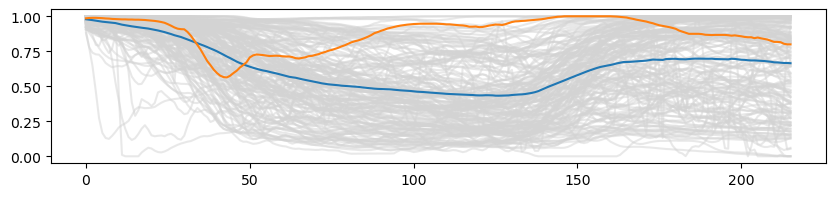

In [6]:
# Validation set identifier
hyper_ = pd.read_csv(path_to_param + f'/{resource}-{method}-hyper.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)
print(hyper_)

asset = 0
time = 72
day = 30

# Get functional predictors for a given test
f_ = F_ts_[day, :time, asset]
e_lin_ = E_ts_lin_[day, :, asset]
e_ = E_ts_[day, :, asset]
x_ts = x_ts_[asset, :]
t_ts = t_ts_[day]
f_hat_ = F_ts_[day, time:, asset]

# Filter solar hours with loading solar set
idx_days_  = np.absolute(t_tr_ - day) < 7
idx_hours_ = (np.sum(F_tr_[idx_days_, :], axis = 0) + np.sum(E_tr_[idx_days_, :], axis = 0)) > 1.

_meta, M_ = _fknn_forecast_dynamic_update(F_tr_, E_tr_lin_, x_tr_, t_tr_, dt_, f_, e_lin_, x_ts, t_ts,
                                          forget_rate_f = hyper_.loc['forget_rate_f'][time],
                                          forget_rate_e = hyper_.loc['forget_rate_e'][time],
                                          length_scale_f = hyper_.loc['length_scale_f'][time],
                                          length_scale_e = hyper_.loc['length_scale_e'][time],
                                          lookup_rate = hyper_.loc['lookup_rate'][time],
                                          trust_rate = hyper_.loc['trust_rate'][time],
                                          nu = hyper_.loc['nu'][time],
                                          gamma = hyper_.loc['gamma'][time],
                                          xi = hyper_.loc['xi'][time],
                                          kappa = hyper_.loc['kappa'][time],
                                          p_fusion = hyper_.loc['trust_rate'][time],
                                          idx_hours_ = idx_hours_)

plt.figure(figsize=(10, 2))
plt.plot(M_.T, color = 'lightgray', alpha = 0.5)
plt.plot(_meta['focal_curve'])
plt.plot(f_hat_)
plt.show()

In [7]:
# Validation set identifier
hyper_ = pd.read_csv(path_to_param + f'/{resource}-{method}-hyper.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)
print(hyper_)

time = 144

M_, f_hat_, e_hat_, focal_, date_, samples_ = _run_parallel(n_workers = 72, 
                                                            assets_ = range(20, 40, 1), 
                                                            indices_ = range(363))

                     72        144       216
parameter                                   
forget_rate_f     0.0625    0.0625    0.0625
forget_rate_e     2.0000    1.0000    0.5000
lookup_rate       2.0000    2.0000    1.0000
length_scale_f    0.0050    0.0050    0.0050
length_scale_e    0.0500    0.0750    0.1000
trust_rate        0.5000    0.3000    0.1000
nu                8.0000    8.0000    8.0000
xi                0.4000    0.5000    0.6000
gamma            60.0000   50.0000   40.0000
kappa           175.0000  150.0000  125.0000
p_fusion          0.6000    0.7000    0.7500
7260 7260 7260 7260 7260 7260


In [8]:
U_ = []
B_ = []
E_ = []
S_ = []
F_ = []
N_ = []
for i in range(len(M_)):
    B_ += [f_hat_[i] - focal_[i]]
    E_ += [np.sqrt(np.mean((f_hat_[i] - e_hat_[i])**2))]
    U_ += [_empirical_PIT(f_hat_[i], M_[i].T, seed = 1234)]
    S_ += [np.std(M_[i], axis = 0).mean()]
    F_ += [focal_[i].mean()]
    N_ += [samples_[i]]
U_ = np.array(U_)
B_ = np.array(B_)
E_ = np.array(E_)
S_ = np.array(S_)
F_ = np.array(F_)
N_ = np.stack(N_)
print(U_.shape, B_.shape, E_.shape, S_.shape, F_.shape, N_.shape)

df_1_ = pd.DataFrame({"date": date_, "std": S_, "mean": F_, "error": E_})
df_1_[['asset', 'day', 'interval']] = df_1_['date'].str.split('-', expand=True)
df_1_['n_neighbors'] = N_[:, 0]
df_1_['n_temporal'] = N_[:, 1]
df_1_['n_spatial'] = N_[:, 2]

df_1_.drop(columns = ['date'], inplace = True)
print(df_1_)

pd.DataFrame(U_).to_csv(path_to_validation + f'/{resource}_{method}_{time}_ts-1.csv', index = False)

(7260, 144) (7260, 144) (7260,) (7260,) (7260,) (7260, 3)
           std      mean     error asset  day interval  n_neighbors  \
0     0.161404  0.164856  0.114288    20    0      144        29926   
1     0.160068  0.167179  0.124710    20    1      144        22480   
2     0.137988  0.137478  0.135629    20    2      144        18911   
3     0.161078  0.164812  0.105027    20    3      144        17452   
4     0.158995  0.165474  0.169301    20    4      144        23118   
...        ...       ...       ...   ...  ...      ...          ...   
7255  0.142219  0.180931  0.174113    39  358      144        16648   
7256  0.250204  0.540217  0.335410    39  359      144         1288   
7257  0.251200  0.443695  0.220585    39  360      144          153   
7258  0.171937  0.195037  0.133548    39  361      144         5200   
7259  0.132907  0.109838  0.109277    39  362      144        23785   

      n_temporal  n_spatial  
0           7179        150  
1           5442        150  

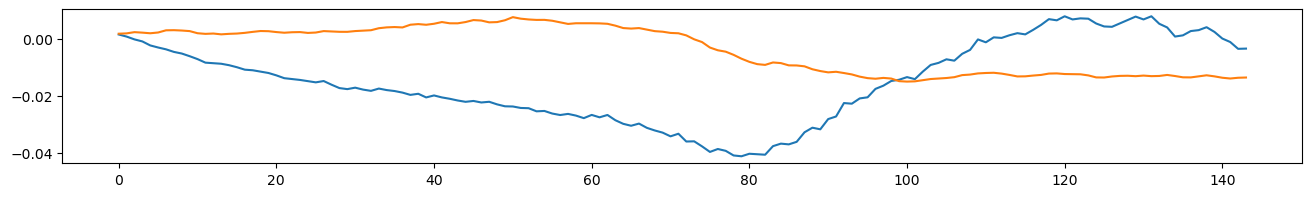

0.04109823062222415 0.01491724575778486


In [9]:
plt.figure(figsize=(16, 2))
plt.plot(np.median(B_, axis = 0))
plt.plot(np.mean(B_, axis = 0))
plt.show()

print(np.absolute(np.median(B_, axis = 0)).max(), np.absolute(np.mean(B_, axis = 0)).max())

(7260, 144) (7260, 3) 150 150
KS for lead time 1h: 0.10112063723839906
KS for lead time 2h: 0.07532617936475008
KS for lead time 3h: 0.047379496103320984
KS for lead time 4h: 0.03941300456371116


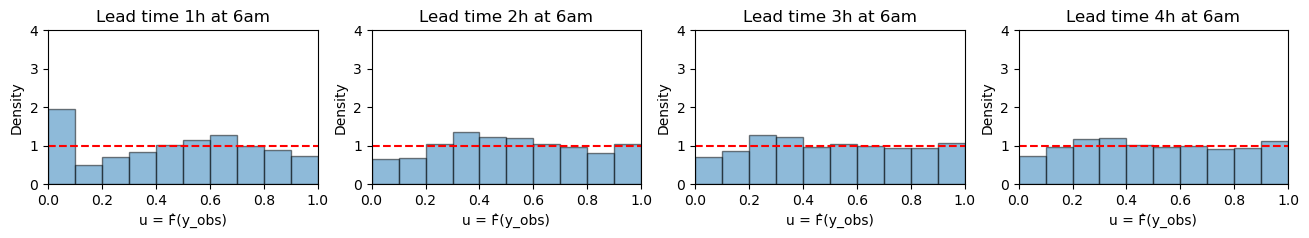

KS over lead times: 0.2632393172701813


In [10]:
print(U_.shape, N_.shape, N_[:, 2].min(), N_[:, 2].max())

lead = 1
bins = 10

# idx_1_ = N_[:, 2] == N_[:, 2].min()
# idx_2_ = (N_[:, 2] > N_[:, 2].min()) & (N_[:, 2] < N_[:, 2].max()) 
# idx_3_ = N_[:, 2] == N_[:, 2].max()
# idx_4_ = idx_1_ | idx_2_ | idx_3_
# idx_5_ = idx_2_ | idx_3_
# print(idx_1_.sum(), idx_2_.sum(), idx_3_.sum(), idx_4_.sum(), idx_5_.sum())

# for idx_ in [idx_1_, idx_2_, idx_3_, idx_4_, idx_5_]:

ttl = 0.

fig, ax = plt.subplots(1, 4, figsize=(16, 2))  

for i in range(4):
    _plot_PIT(ax[i], U_[:, (i + lead)*12], 
                bins = bins, 
                title = f'Lead time {i + lead}h at 6am')
    
    ax[i].set_ylim(0, 4)
    
    KS = _KS(U_[:, (i + lead)*12])
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')

KS for lead time 2h: 0.053166896235077976
KS for lead time 3h: 0.02292814508723595
KS for lead time 4h: 0.028315853396360238
KS for lead time 5h: 0.023453856749311303
KS for lead time 6h: 0.01946854912764004


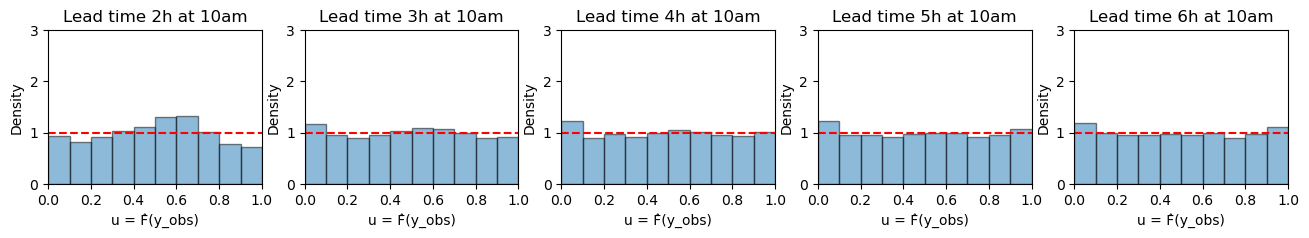

KS over lead times: 0.14733330059562552


In [11]:
lead = 2
bins = 10
n_intervals = 5

# idx_1_ = N_[:, 2] == N_[:, 2].min()
# idx_2_ = (N_[:, 2] > N_[:, 2].min()) & (N_[:, 2] < N_[:, 2].max()) 
# idx_3_ = N_[:, 2] == N_[:, 2].max()
# idx_4_ = idx_1_ | idx_2_ | idx_3_
# idx_5_ = idx_2_ | idx_3_
# print(idx_1_.sum(), idx_2_.sum(), idx_3_.sum(), idx_4_.sum(), idx_5_.sum())

# for idx_ in [idx_1_, idx_2_, idx_3_, idx_4_, idx_5_]:

ttl = 0.
    
fig, ax = plt.subplots(1, n_intervals, figsize=(16, 2))  

for i in range(n_intervals):
    _plot_PIT(ax[i], U_[:, i*12:(i + lead)*12].flatten(), 
                bins = bins, 
                title = f'Lead time {i + lead}h at 10am')
    ax[i].set_ylim(0, 3)
    
    KS = _KS(U_[:, i*12:(i + lead)*12].flatten())
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')

In [ ]:
# Validation set identifier
hyper_ = pd.read_csv(path_to_param + f'/{resource}-{method}-hyper.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)

hyper_.loc['forget_rate_e', time] = 0.5
hyper_.loc['length_scale_e', time] = 0.05
# hyper_.loc['lookup_rate', time] = 1
# hyper_.loc['gamma', time] = 40
# hyper_.loc['kappa', time] = 125
# hyper_.loc['p_fusion', time] = 0.75

print(hyper_)

time = 144

M_, f_hat_, e_hat_, focal_, date_, samples_ = _run_parallel(n_workers = 72, 
                                                            assets_ = range(20, 40, 1), 
                                                            indices_ = range(363))

                     72        144       216
parameter                                   
forget_rate_f     0.0625    0.0625    0.0625
forget_rate_e     2.0000    0.5000    0.5000
lookup_rate       2.0000    2.0000    1.0000
length_scale_f    0.0050    0.0050    0.0050
length_scale_e    0.0500    0.0500    0.1000
trust_rate        0.5000    0.3000    0.1000
nu                8.0000    8.0000    8.0000
xi                0.4000    0.5000    0.6000
gamma            60.0000   50.0000   40.0000
kappa           175.0000  150.0000  125.0000
p_fusion          0.6000    0.7000    0.7500


In [ ]:
U_ = []
B_ = []
E_ = []
S_ = []
F_ = []
N_ = []
for i in range(len(M_)):
    B_ += [f_hat_[i] - focal_[i]]
    E_ += [np.sqrt(np.mean((f_hat_[i] - e_hat_[i])**2))]
    U_ += [_empirical_PIT(f_hat_[i], M_[i].T, seed = 1234)]
    S_ += [np.std(M_[i], axis = 0).mean()]
    F_ += [focal_[i].mean()]
    N_ += [samples_[i]]
U_ = np.array(U_)
B_ = np.array(B_)
E_ = np.array(E_)
S_ = np.array(S_)
F_ = np.array(F_)
N_ = np.stack(N_)
print(U_.shape, B_.shape, E_.shape, S_.shape, F_.shape, N_.shape)

df_2_ = pd.DataFrame({"date": date_, "std": S_, "mean": F_, "error": E_})
df_2_[['asset', 'day', 'interval']] = df_2_['date'].str.split('-', expand=True)
df_2_['n_neighbors'] = N_[:, 0]
df_2_['n_temporal'] = N_[:, 1]
df_2_['n_spatial'] = N_[:, 2]

df_2_.drop(columns = ['date'], inplace = True)
print(df_2_)

pd.DataFrame(U_).to_csv(path_to_validation + f'/{resource}_{method}_{time}_ts-2.csv', index = False)

(7260, 144) (7260, 144) (7260,) (7260,) (7260,) (7260, 3)
           std      mean     error asset  day interval  n_neighbors  \
0     0.183342  0.179423  0.114288    20    0      144        30627   
1     0.183411  0.182638  0.124710    20    1      144        22536   
2     0.168521  0.164809  0.135629    20    2      144        19627   
3     0.172769  0.177102  0.105027    20    3      144        17245   
4     0.180742  0.173040  0.169301    20    4      144        23291   
...        ...       ...       ...   ...  ...      ...          ...   
7255  0.136845  0.158720  0.174113    39  358      144        15879   
7256  0.237939  0.611152  0.335410    39  359      144         1238   
7257  0.252308  0.577650  0.220585    39  360      144          334   
7258  0.215202  0.227467  0.133548    39  361      144         4425   
7259  0.136666  0.115338  0.109277    39  362      144        22924   

      n_temporal  n_spatial  
0           6028        125  
1           4326        125  

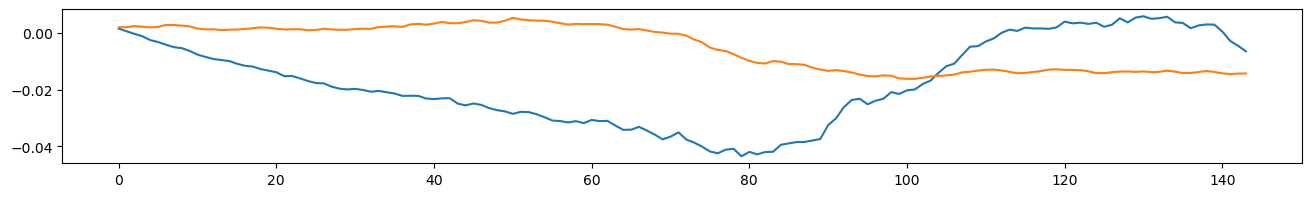

0.04344234378758065 0.016251396856046506


In [ ]:
plt.figure(figsize=(16, 2))
plt.plot(np.median(B_, axis = 0))
plt.plot(np.mean(B_, axis = 0))
plt.show()

print(np.absolute(np.median(B_, axis = 0)).max(), np.absolute(np.mean(B_, axis = 0)).max())

(7260, 144) (7260, 3) 125 125
KS for lead time 1h: 0.10031392905024561
KS for lead time 2h: 0.07600925962468794
KS for lead time 3h: 0.04449035812672178
KS for lead time 4h: 0.030876872694084317


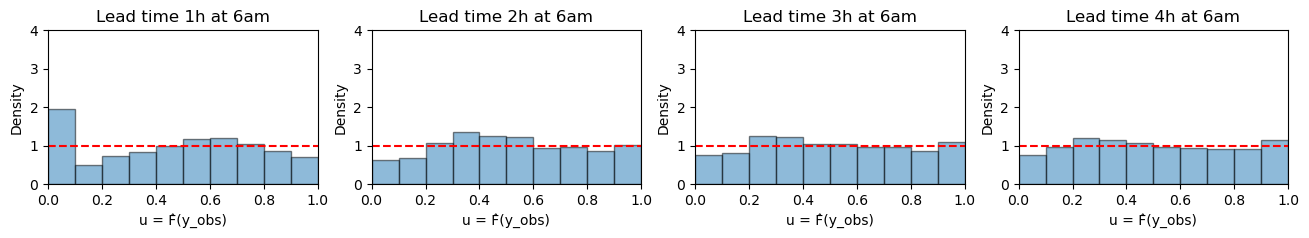

KS over lead times: 0.25169041949573967


In [ ]:
print(U_.shape, N_.shape, N_[:, 2].min(), N_[:, 2].max())

lead = 1
bins = 10

# idx_1_ = N_[:, 2] == N_[:, 2].min()
# idx_2_ = (N_[:, 2] > N_[:, 2].min()) & (N_[:, 2] < N_[:, 2].max()) 
# idx_3_ = N_[:, 2] == N_[:, 2].max()
# idx_4_ = idx_1_ | idx_2_ | idx_3_
# idx_5_ = idx_2_ | idx_3_
# print(idx_1_.sum(), idx_2_.sum(), idx_3_.sum(), idx_4_.sum(), idx_5_.sum())

# for idx_ in [idx_1_, idx_2_, idx_3_, idx_4_, idx_5_]:

ttl = 0.

fig, ax = plt.subplots(1, 4, figsize=(16, 2))  

for i in range(4):
    _plot_PIT(ax[i], U_[:, (i + lead)*12], 
                bins = bins, 
                title = f'Lead time {i + lead}h at 6am')
    
    ax[i].set_ylim(0, 4)
    
    KS = _KS(U_[:, (i + lead)*12])
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')

KS for lead time 2h: 0.05330968778696055
KS for lead time 3h: 0.022897612488521513
KS for lead time 4h: 0.030748622589531677
KS for lead time 5h: 0.030464416896235053
KS for lead time 6h: 0.02973433432418146


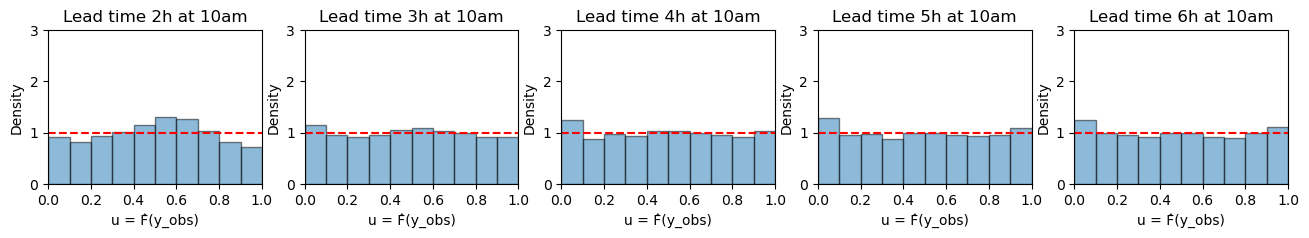

KS over lead times: 0.16715467408543025


In [ ]:
lead = 2
bins = 10
n_intervals = 5

# idx_1_ = N_[:, 2] == N_[:, 2].min()
# idx_2_ = (N_[:, 2] > N_[:, 2].min()) & (N_[:, 2] < N_[:, 2].max()) 
# idx_3_ = N_[:, 2] == N_[:, 2].max()
# idx_4_ = idx_1_ | idx_2_ | idx_3_
# idx_5_ = idx_2_ | idx_3_
# print(idx_1_.sum(), idx_2_.sum(), idx_3_.sum(), idx_4_.sum(), idx_5_.sum())

# for idx_ in [idx_1_, idx_2_, idx_3_, idx_4_, idx_5_]:

ttl = 0.

fig, ax = plt.subplots(1, n_intervals, figsize=(16, 2))  

for i in range(n_intervals):
    _plot_PIT(ax[i], U_[:, i*12:(i + lead)*12].flatten(), 
                bins = bins, 
                title = f'Lead time {i + lead}h at 10am')
    ax[i].set_ylim(0, 3)
    
    KS = _KS(U_[:, i*12:(i + lead)*12].flatten())
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')
# KS for lead time 2h: 0.05270546372819107

In [ ]:
# Validation set identifier
hyper_ = pd.read_csv(path_to_param + f'/{resource}-{method}-hyper.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)

hyper_.loc['forget_rate_e', time] = 0.5
hyper_.loc['length_scale_e', time] = 0.1
# hyper_.loc['lookup_rate', time] = 1
# hyper_.loc['gamma', time] = 40
# hyper_.loc['kappa', time] = 125
# hyper_.loc['p_fusion', time] = 0.75

print(hyper_)

time = 144

M_, f_hat_, e_hat_, focal_, date_, samples_ = _run_parallel(n_workers = 72, 
                                                            assets_ = range(20, 40, 1), 
                                                            indices_ = range(363))

                     72        144       216
parameter                                   
forget_rate_f     0.0625    0.0625    0.0625
forget_rate_e     2.0000    0.5000    0.5000
lookup_rate       2.0000    1.0000    1.0000
length_scale_f    0.0050    0.0050    0.0050
length_scale_e    0.0500    0.0750    0.1000
trust_rate        0.5000    0.3000    0.1000
nu                8.0000    8.0000    8.0000
xi                0.4000    0.5000    0.6000
gamma            60.0000   40.0000   40.0000
kappa           175.0000  125.0000  125.0000
p_fusion          0.6000    0.7500    0.7500
7260 7260 7260 7260 7260 7260


In [ ]:
U_ = []
B_ = []
E_ = []
S_ = []
F_ = []
N_ = []
for i in range(len(M_)):
    B_ += [f_hat_[i] - focal_[i]]
    E_ += [np.sqrt(np.mean((f_hat_[i] - e_hat_[i])**2))]
    U_ += [_empirical_PIT(f_hat_[i], M_[i].T, seed = 1234)]
    S_ += [np.std(M_[i], axis = 0).mean()]
    F_ += [focal_[i].mean()]
    N_ += [samples_[i]]
U_ = np.array(U_)
B_ = np.array(B_)
E_ = np.array(E_)
S_ = np.array(S_)
F_ = np.array(F_)
N_ = np.stack(N_)
print(U_.shape, B_.shape, E_.shape, S_.shape, F_.shape, N_.shape)

df_3_ = pd.DataFrame({"date": date_, "std": S_, "mean": F_, "error": E_})
df_3_[['asset', 'day', 'interval']] = df_3_['date'].str.split('-', expand=True)
df_3_['n_neighbors'] = N_[:, 0]
df_3_['n_temporal'] = N_[:, 1]
df_3_['n_spatial'] = N_[:, 2]
df_3_.drop(columns = ['date'], inplace = True)

pd.DataFrame(U_).to_csv(path_to_validation + f'/{resource}_{method}_{time}_ts-3.csv', index = False)

(7260, 144) (7260, 144) (7260,) (7260,) (7260,) (7260, 3)


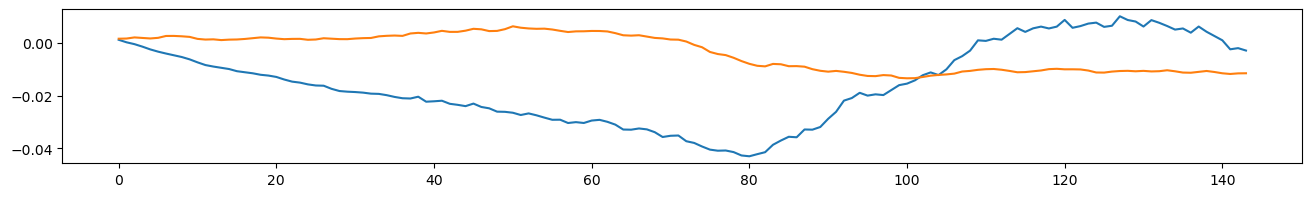

0.04301491073268392 0.013345497487032126


In [ ]:
plt.figure(figsize=(16, 2))
plt.plot(np.median(B_, axis = 0))
plt.plot(np.mean(B_, axis = 0))
plt.show()

print(np.absolute(np.median(B_, axis = 0)).max(), np.absolute(np.mean(B_, axis = 0)).max())

(7260, 144) (7260, 3) 125 125
KS for lead time 1h: 0.10180716253443528
KS for lead time 2h: 0.07534259295802126
KS for lead time 3h: 0.04472522060109971
KS for lead time 4h: 0.032152382674551755


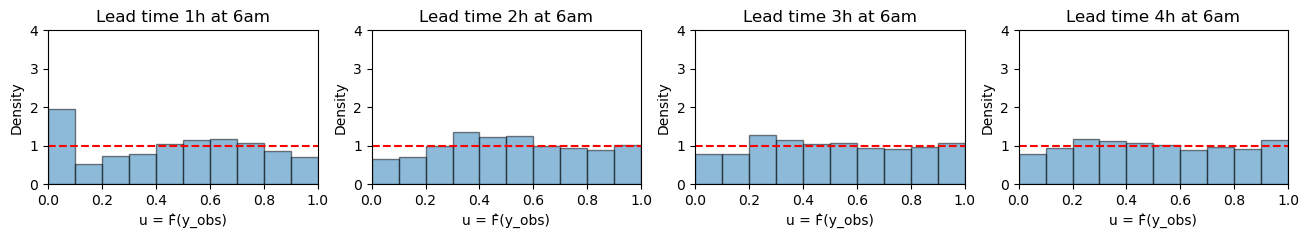

KS over lead times: 0.254027358768108


In [ ]:
print(U_.shape, N_.shape, N_[:, 2].min(), N_[:, 2].max())

lead = 1
bins = 10

# idx_1_ = N_[:, 2] == N_[:, 2].min()
# idx_2_ = (N_[:, 2] > N_[:, 2].min()) & (N_[:, 2] < N_[:, 2].max()) 
# idx_3_ = N_[:, 2] == N_[:, 2].max()
# idx_4_ = idx_1_ | idx_2_ | idx_3_
# idx_5_ = idx_2_ | idx_3_

# print(idx_1_.sum(), idx_2_.sum(), idx_3_.sum(), idx_4_.sum(), idx_5_.sum())

# for idx_ in [idx_1_, idx_2_, idx_3_, idx_4_, idx_5_]:

ttl = 0.

fig, ax = plt.subplots(1, 4, figsize=(16, 2))  

for i in range(4):
    _plot_PIT(ax[i], U_[:, (i + lead)*12], 
                bins = bins, 
                title = f'Lead time {i + lead}h at 6am')
    
    ax[i].set_ylim(0, 4)
    
    KS = _KS(U_[:, (i + lead)*12])
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')

KS for lead time 2h: 0.05199540863177221
KS for lead time 3h: 0.02176635666418375
KS for lead time 4h: 0.0321489898989899
KS for lead time 5h: 0.03152617079889805
KS for lead time 6h: 0.028752929365503777


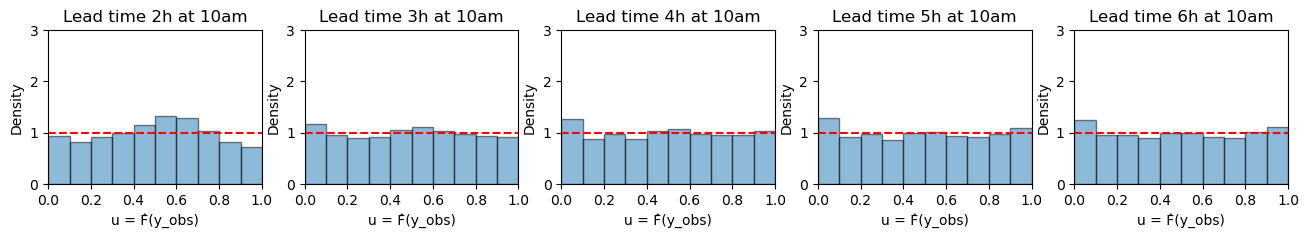

KS over lead times: 0.1661898553593477


In [ ]:
lead = 2
bins = 10
n_intervals = 5

# idx_1_ = N_[:, 2] == N_[:, 2].min()
# idx_2_ = (N_[:, 2] > N_[:, 2].min()) & (N_[:, 2] < N_[:, 2].max()) 
# idx_3_ = N_[:, 2] == N_[:, 2].max()
# idx_4_ = idx_1_ | idx_2_ | idx_3_
# idx_5_ = idx_2_ | idx_3_
# print(idx_1_.sum(), idx_2_.sum(), idx_3_.sum(), idx_4_.sum(), idx_5_.sum())

# for idx_ in [idx_1_, idx_2_, idx_3_, idx_4_, idx_5_]:

ttl = 0.

fig, ax = plt.subplots(1, n_intervals, figsize=(16, 2))  

for i in range(n_intervals):
    _plot_PIT(ax[i], U_[:, i*12:(i + lead)*12].flatten(), 
                bins = bins, 
                title = f'Lead time {i + lead}h at 10am')
    ax[i].set_ylim(0, 3)
    
    KS = _KS(U_[:, i*12:(i + lead)*12].flatten())
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')
# KS for lead time 2h: 0.04066087962962961
# KS over lead times: 0.042971643518518454
# KS for lead time 2h: 0.03425289351851857

In [27]:
df_ = pd.concat([df_1_, df_2_, df_3_], axis = 0)    
print(df_.shape)

df_.to_csv(path_to_validation + f'/{resource}_{method}_dispersion_ts.csv', index = False)

(17400, 9)
